In [30]:
import numpy as np
from scipy import stats
from math import factorial
import matplotlib.pyplot as plt

In [31]:
# Ex 1:
def g1(A,i):
    if i < 0 or i > m:
        return 0.0
    return A ** i / factorial(i)

def mh_truncated_poisson_1(x0,n_samples,A, burn_in=1000):

    np.random.seed(42)

    samples = np.empty(n_samples, dtype=int)

    for i in range(-burn_in, n_samples):
        y = x0 + np.random.choice((-1, 1))
        if np.random.uniform() < min(1.0, g1(A,y) / g1(A,x0)):
            x0 = y
        if i >= 0:
            samples[i] = x0

    return samples

def plot_mh_vs_true(states, observed, n_samples, true_pmf, A, m, dof=None, p_value=None, width=0.4, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure

    ax.bar(states - width / 2, observed / n_samples, width=width, label="MH samples (relative freq.)")
    ax.bar(states + width / 2, true_pmf, width=width, label="True P(i) = c A^i / i!")
    ax.set_xlabel("i (number of busy lines)")
    ax.set_ylabel("Probability")
    ax.set_title(f"Truncated Poisson, A={A}, m={m}: MH samples vs. true distribution")
    ax.set_xticks(states)
    ax.legend()

    fig.tight_layout()
    return fig, ax

A = 8.0, m = 10, n_samples = 100000

  i   observed   expected  true P(i)
  0         45      41.12     0.0004
  1        335     328.93     0.0033
  2       1329    1315.72     0.0132
  3       3483    3508.60     0.0351
  4       6965    7017.19     0.0702
  5      11099   11227.51     0.1123
  6      14715   14970.01     0.1497
  7      17024   17108.59     0.1711
  8      17306   17108.59     0.1711
  9      15423   15207.63     0.1521
 10      12276   12166.11     0.1217

Chi-square statistic: 13.742
Degrees of freedom:   10
p-value:              0.1851


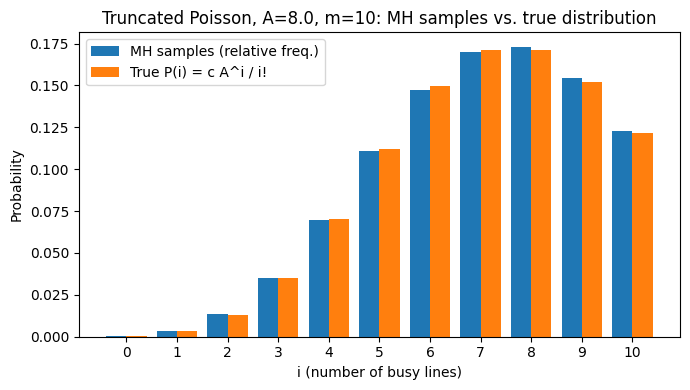

In [32]:
A = 8.0
m = 10

states = np.arange(m + 1)
g_vals = np.array([g1(A,i) for i in states])
true_pmf = g_vals / g_vals.sum()

n_samples = 100000
rng = np.random.seed(42)

samples = mh_truncated_poisson_1(m//2,n_samples,A, burn_in=10000)

observed = np.array([np.sum(samples == i) for i in states])
expected = true_pmf * n_samples

chi2_stat, p_value = stats.chisquare(observed, f_exp=expected)
dof = m

print(f"A = {A}, m = {m}, n_samples = {n_samples}\n")
print(f"{'i':>3}  {'observed':>9}  {'expected':>9}  {'true P(i)':>9}")
for i in states:
    print(f"{i:>3}  {observed[i]:>9}  {expected[i]:>9.2f}  {true_pmf[i]:>9.4f}")

print(f"\nChi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.4f}")

fig, ax = plot_mh_vs_true(states, observed, n_samples, true_pmf, A, m, dof=dof, p_value=p_value)
plt.show()

In [33]:
# Ex 2(a)
def g2(A1, A2, i, j):
    if i < 0 or j < 0 or i + j > m:
        return 0.0
    return A1 ** i / factorial(i) * A2 ** j / factorial(j)

def mh_truncated_poisson_2(x0, n_samples, A1, A2, burn_in=1000):
    moves = np.array([(1, 0), (-1, 0), (0, 1), (0, -1)])
    x = np.array(x0, dtype=int)
    samples = np.empty((n_samples, 2), dtype=int)

    for i in range(-burn_in, n_samples):
        y = x + moves[np.random.choice(4)]
        if np.random.uniform() < min(1.0, g2(A1, A2, y[0], y[1]) / g2(A1, A2, x[0], x[1])):
            x = y
        if i >= 0:
            samples[i] = x

    return samples

def plot_mh_vs_true_2d(observed, true_pmf, n_samples, A1, A2, m, dof=None, p_value=None, ax=None):
    grid = m + 1
    ii, jj = np.meshgrid(np.arange(grid), np.arange(grid), indexing="ij")
    mask = (ii + jj) > m

    observed_freq = np.ma.array(observed / n_samples, mask=mask)
    true_pmf_masked = np.ma.array(true_pmf, mask=mask)
    vmax = max(observed_freq.max(), true_pmf_masked.max())

    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    else:
        fig = ax[0].figure

    im0 = ax[0].imshow(observed_freq.T, origin="lower", vmin=0, vmax=vmax, cmap="viridis")
    ax[0].set_title("MH samples (relative freq.)")

    im1 = ax[1].imshow(true_pmf_masked.T, origin="lower", vmin=0, vmax=vmax, cmap="viridis")
    ax[1].set_title("True P(i,j) = c A1^i/i! A2^j/j!")

    for a in ax:
        a.set_xlabel("i")
        a.set_ylabel("j")
        a.set_xticks(range(grid))
        a.set_yticks(range(grid))

    fig.suptitle(f"Joint truncated Poisson, A1={A1}, A2={A2}, m={m}")
    fig.colorbar(im1, ax=ax.tolist(), shrink=0.8, label="Probability")

    return fig, ax

A1 = 4, A2 = 4, m = 10, n_samples = 100000

Chi-square statistic: 446.585
Degrees of freedom:   65
p-value:              0.0000


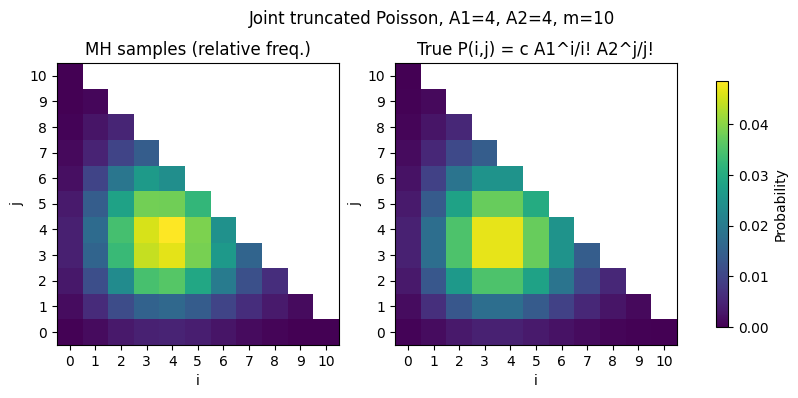

In [34]:
A1 = 4
A2 = 4
m = 10

ii, jj = np.meshgrid(np.arange(m + 1), np.arange(m + 1), indexing="ij")
valid = (ii + jj) <= m

g2_vals = np.zeros((m + 1, m + 1))
g2_vals[valid] = [g2(A1, A2, i, j) for i, j in zip(ii[valid], jj[valid])]
true_pmf = g2_vals / g2_vals.sum()

n_samples = 100000

samples = mh_truncated_poisson_2((m // 2, 0), n_samples, A1, A2, burn_in=1000)

observed = np.zeros((m + 1, m + 1))
for i, j in samples:
    observed[i, j] += 1

expected = true_pmf[valid] * n_samples
chi2_stat, p_value = stats.chisquare(observed[valid], f_exp=expected)
dof = valid.sum() - 1

print(f"A1 = {A1}, A2 = {A2}, m = {m}, n_samples = {n_samples}\n")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.4f}")

fig, ax = plot_mh_vs_true_2d(observed, true_pmf, n_samples, A1, A2, m, dof=dof, p_value=p_value)
plt.show()

In [35]:
# Ex 2(b)
def mh_truncated_poisson_2_coordwise(x0, n_samples, A1, A2, burn_in=1000):
    np.random.seed(42)

    x = np.array(x0, dtype=int)
    samples = np.empty((n_samples, 2), dtype=int)

    for i in range(-burn_in, n_samples):
        for coord in range(2):
            y = x.copy()
            y[coord] += np.random.choice((-1, 1))
            if np.random.uniform() < min(1.0, g2(A1, A2, y[0], y[1]) / g2(A1, A2, x[0], x[1])):
                x = y
        if i >= 0:
            samples[i] = x

    return samples

A1 = 4, A2 = 4, m = 10, n_samples = 100000

Chi-square statistic: 135.543
Degrees of freedom:   65
p-value:              0.0000


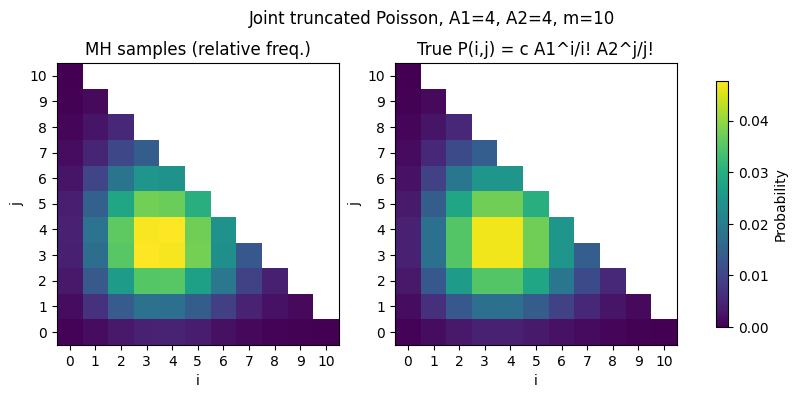

In [36]:
samples_cw = mh_truncated_poisson_2_coordwise((m // 2, 0), n_samples, A1, A2, burn_in=1000)

observed_cw = np.zeros((m + 1, m + 1))
for i, j in samples_cw:
    observed_cw[i, j] += 1

expected_cw = true_pmf[valid] * n_samples
chi2_stat_cw, p_value_cw = stats.chisquare(observed_cw[valid], f_exp=expected_cw)
dof_cw = valid.sum() - 1

print(f"A1 = {A1}, A2 = {A2}, m = {m}, n_samples = {n_samples}\n")
print(f"Chi-square statistic: {chi2_stat_cw:.3f}")
print(f"Degrees of freedom:   {dof_cw}")
print(f"p-value:              {p_value_cw:.4f}")

fig, ax = plot_mh_vs_true_2d(observed_cw, true_pmf, n_samples, A1, A2, m, dof=dof_cw, p_value=p_value_cw)
plt.show()

In [37]:
# Ex 2(c)
def sample_truncated_poisson(A, M):
    k = np.arange(M + 1)
    weights = A ** k / np.array([factorial(kk) for kk in k])
    probs = weights / weights.sum()
    return np.random.choice(k, p=probs)

def gibbs_truncated_poisson_2(x0, n_samples, A1, A2, burn_in=1000):
    np.random.seed(42)

    x = np.array(x0, dtype=int)
    samples = np.empty((n_samples, 2), dtype=int)

    for it in range(-burn_in, n_samples):
        x[0] = sample_truncated_poisson(A1, m - x[1])
        x[1] = sample_truncated_poisson(A2, m - x[0])
        if it >= 0:
            samples[it] = x

    return samples


A1 = 4, A2 = 4, m = 10, n_samples = 100000

Chi-square statistic: 35.914
Degrees of freedom:   65
p-value:              0.9987


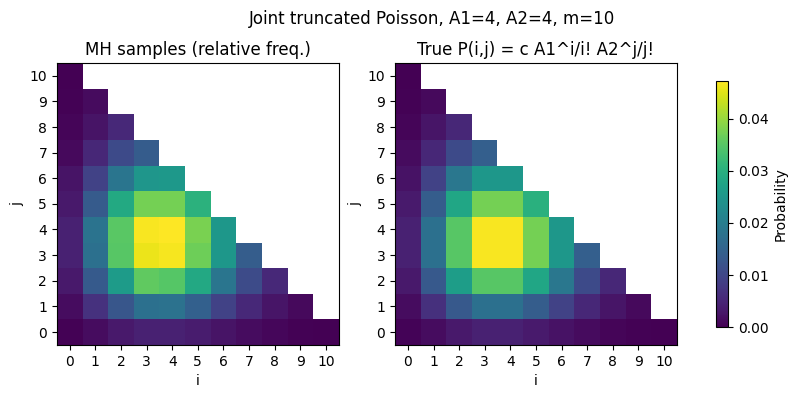

In [38]:
samples_gibbs = gibbs_truncated_poisson_2((m // 2, 0), n_samples, A1, A2, burn_in=1000)

observed_gibbs = np.zeros((m + 1, m + 1))
for i, j in samples_gibbs:
    observed_gibbs[i, j] += 1

expected_gibbs = true_pmf[valid] * n_samples
chi2_stat_gibbs, p_value_gibbs = stats.chisquare(observed_gibbs[valid], f_exp=expected_gibbs)
dof_gibbs = valid.sum() - 1

print(f"A1 = {A1}, A2 = {A2}, m = {m}, n_samples = {n_samples}\n")
print(f"Chi-square statistic: {chi2_stat_gibbs:.3f}")
print(f"Degrees of freedom:   {dof_gibbs}")
print(f"p-value:              {p_value_gibbs:.4f}")

fig, ax = plot_mh_vs_true_2d(observed_gibbs, true_pmf, n_samples, A1, A2, m, dof=dof_gibbs, p_value=p_value_gibbs)
plt.show()


In [39]:
# Part 3(a)

rho = 0.5
rng_prior = np.random.default_rng(seed=0)

cov_prior = np.array([[1.0, rho], [rho, 1.0]])
xi_true, gamma_true = rng_prior.multivariate_normal([0.0, 0.0], cov_prior)
theta_true = np.exp(xi_true)
psi_true   = np.exp(gamma_true)

print(f"Sampled prior values:")
print(f"  xi    = {xi_true:.4f},  gamma  = {gamma_true:.4f}")
print(f"  theta = {theta_true:.4f},  psi    = {psi_true:.4f}")

Sampled prior values:
  xi    = -0.0428,  gamma  = -0.1749
  theta = 0.9581,  psi    = 0.8395


In [40]:
# Part 3(b)

def simulate_data(theta, psi, n, seed=1):
    rng = np.random.default_rng(seed)
    return rng.normal(loc=theta, scale=np.sqrt(psi), size=n)

x_obs_10 = simulate_data(theta_true, psi_true, n=10)
print(f"n=10  observations: {np.round(x_obs_10, 3)}")
print(f"sample mean = {x_obs_10.mean():.4f},  sample variance = {x_obs_10.var(ddof=1):.4f}")

n=10  observations: [ 1.275  1.711  1.261 -0.236  1.788  1.367  0.466  1.491  1.292  1.228]
sample mean = 1.1641,  sample variance = 0.3694


In [41]:
# Part 3(d)

def log_unnorm_posterior(xi, gamma, x_obs, rho=0.5):
    n = len(x_obs)
    theta = np.exp(xi)
    psi   = np.exp(gamma)
    log_prior = -(xi**2 - 2*rho*xi*gamma + gamma**2) / (2*(1 - rho**2))
    log_lik   = -0.5*n*gamma - 0.5*np.sum((x_obs - theta)**2) / psi
    return log_prior + log_lik

def mh_posterior(x_obs, n_samples=100_000, sigma_prop=0.3, burn_in=10_000, seed=42):
    rng = np.random.default_rng(seed)
    xi, gamma = 0.0, 0.0
    log_p = log_unnorm_posterior(xi, gamma, x_obs)
    samples = np.empty((n_samples, 2))
    n_accept = 0

    for i in range(-burn_in, n_samples):
        xi_p    = xi    + rng.normal(0, sigma_prop)
        gamma_p = gamma + rng.normal(0, sigma_prop)
        log_p_p = log_unnorm_posterior(xi_p, gamma_p, x_obs)

        if np.log(rng.random()) < log_p_p - log_p:
            xi, gamma, log_p = xi_p, gamma_p, log_p_p
            if i >= 0:
                n_accept += 1

        if i >= 0:
            samples[i] = [xi, gamma]

    accept_rate = n_accept / n_samples
    return samples, accept_rate

def plot_posterior(samples, xi_true, gamma_true, n, ax=None):
    xi_s, gamma_s = samples[:, 0], samples[:, 1]
    if ax is None:
        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    else:
        axes = ax
        fig = axes[0].figure

    axes[0].plot(xi_s[:2000], alpha=0.6, lw=0.6)
    axes[0].axhline(xi_true, color="r", lw=1.5, label=f"true ξ={xi_true:.2f}")
    axes[0].set_title(f"Trace of ξ (n={n})")
    axes[0].set_ylabel("ξ = log θ")
    axes[0].legend(fontsize=8)

    axes[1].plot(gamma_s[:2000], alpha=0.6, lw=0.6)
    axes[1].axhline(gamma_true, color="r", lw=1.5, label=f"true γ={gamma_true:.2f}")
    axes[1].set_title(f"Trace of γ (n={n})")
    axes[1].set_ylabel("γ = log ψ")
    axes[1].legend(fontsize=8)

    axes[2].scatter(xi_s[::20], gamma_s[::20], s=1, alpha=0.3)
    axes[2].scatter([xi_true], [gamma_true], color="r", zorder=5, label="true")
    axes[2].set_xlabel("ξ = log θ")
    axes[2].set_ylabel("γ = log ψ")
    axes[2].set_title(f"Joint posterior scatter (n={n})")
    axes[2].legend(fontsize=8)

    fig.tight_layout()
    return fig, axes

n=10  | acceptance rate: 0.522
       posterior mean: xi=0.064 (true -0.043),  gamma=-0.654 (true -0.175)
       posterior std:  xi=0.235,  gamma=0.458


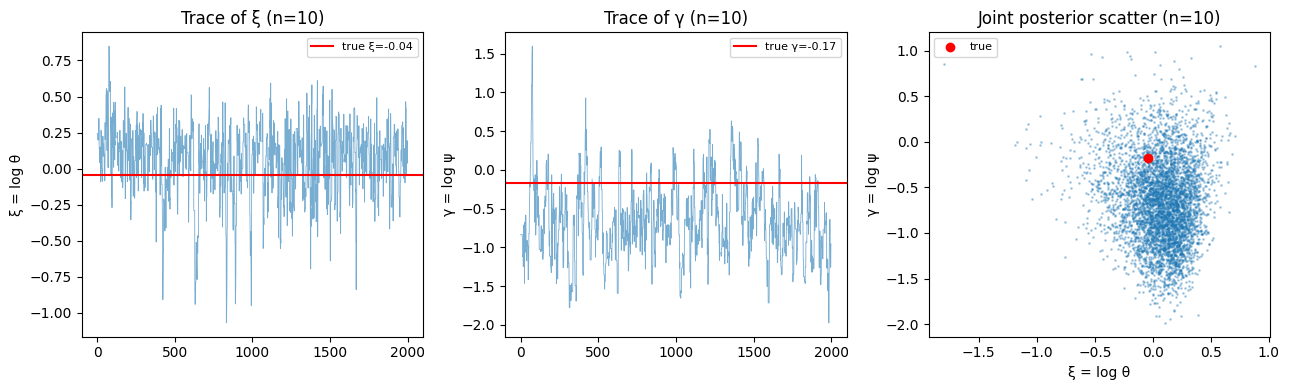

In [42]:
# Part 3(d)
samples_10, acc_10 = mh_posterior(x_obs_10, n_samples=100_000, sigma_prop=0.3, burn_in=10_000)

xi_s10, gamma_s10 = samples_10[:, 0], samples_10[:, 1]
print(f"n=10  | acceptance rate: {acc_10:.3f}")
print(f"       posterior mean: xi={xi_s10.mean():.3f} (true {xi_true:.3f}),  "
      f"gamma={gamma_s10.mean():.3f} (true {gamma_true:.3f})")
print(f"       posterior std:  xi={xi_s10.std():.3f},  gamma={gamma_s10.std():.3f}")

fig, _ = plot_posterior(samples_10, xi_true, gamma_true, n=10)
plt.show()

n=100  | acceptance rate: 0.435
        posterior mean: xi=-0.128 (true -0.043),  gamma=-0.466 (true -0.175)
        posterior std:  xi=0.091,  gamma=0.143

n=1000 | acceptance rate: 0.439
        posterior mean: xi=-0.098 (true -0.043),  gamma=-0.200 (true -0.175)
        posterior std:  xi=0.032,  gamma=0.045



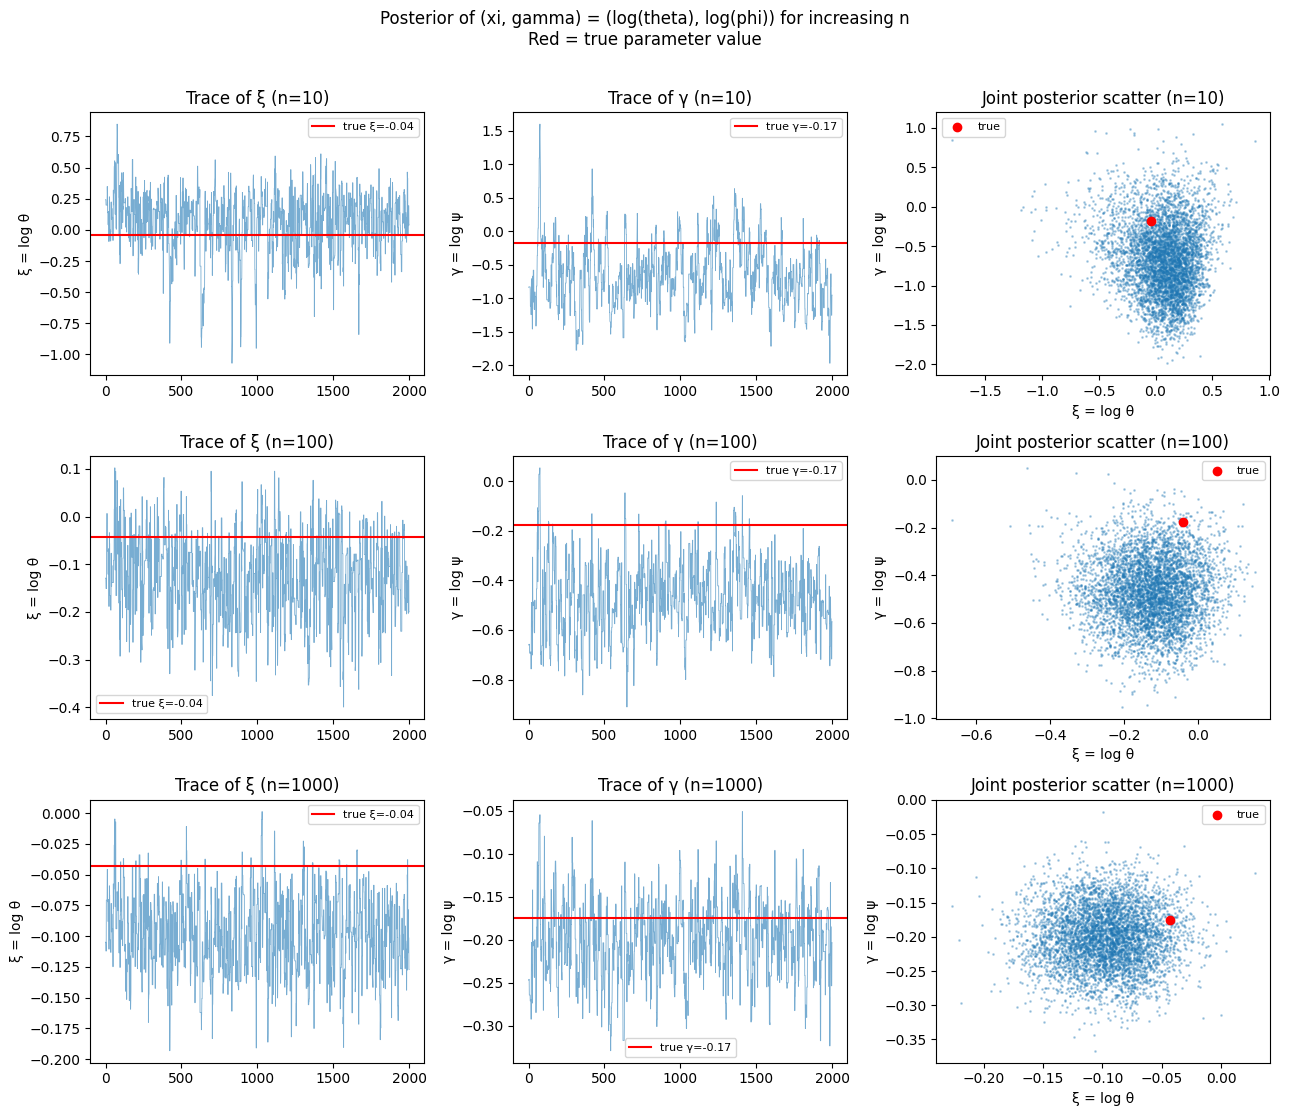

In [43]:
# Part 3(e)
x_obs_100  = simulate_data(theta_true, psi_true, n=100,  seed=1)
x_obs_1000 = simulate_data(theta_true, psi_true, n=1000, seed=1)

samples_100,  acc_100  = mh_posterior(x_obs_100,  n_samples=100_000, sigma_prop=0.15, burn_in=10_000)
samples_1000, acc_1000 = mh_posterior(x_obs_1000, n_samples=100_000, sigma_prop=0.05, burn_in=10_000)

for n, samp, acc in [(100, samples_100, acc_100), (1000, samples_1000, acc_1000)]:
    xi_s, gamma_s = samp[:, 0], samp[:, 1]
    print(f"n={n:<4} | acceptance rate: {acc:.3f}")
    print(f"        posterior mean: xi={xi_s.mean():.3f} (true {xi_true:.3f}),  "
          f"gamma={gamma_s.mean():.3f} (true {gamma_true:.3f})")
    print(f"        posterior std:  xi={xi_s.std():.3f},  gamma={gamma_s.std():.3f}\n")

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
plot_posterior(samples_10,   xi_true, gamma_true, n=10,   ax=axes[0])
plot_posterior(samples_100,  xi_true, gamma_true, n=100,  ax=axes[1])
plot_posterior(samples_1000, xi_true, gamma_true, n=1000, ax=axes[2])
fig.suptitle(
    "Posterior of (xi, gamma) = (log(theta), log(phi)) for increasing n\n"
    "Red = true parameter value",
    y=1.01
)
plt.tight_layout()
plt.show()